In [1]:
# Colab + local compatible loader (downloads CSV if not present)
import os
import numpy as np
import pandas as pd

CANDIDATES = ['diabetes.csv', 'lab06/diabetes.csv', '/content/diabetes.csv']
data_path = next((x for x in CANDIDATES if os.path.exists(x)), None)
if data_path is None:
    url = 'https://raw.githubusercontent.com/manaal6/Introduction_To_AI_Lab_Tasks/main/lab06/diabetes.csv'
    print('Downloading:', url)
    data_path = 'diabetes.csv'
    pd.read_csv(url).to_csv(data_path, index=False)
print('Using:', data_path)
df = pd.read_csv(data_path, encoding='ascii', delimiter=',')

df.head()


Using: diabetes.csv


,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,148,72.0,35,169.5,33.6,0.627,50,1
1,85,66.0,29,102.5,26.6,0.351,31,0
2,183,64.0,32,169.5,23.3,0.672,32,1
3,89,66.0,23,94.0,28.1,0.167,21,0
4,137,40.0,35,168.0,43.1,2.288,33,1


In [2]:
from sklearn.model_selection import train_test_split
# Prepare features and target variable
X = df[['Age', 'BMI', 'BloodPressure', 'Insulin', 'Glucose', 'DiabetesPedigreeFunction']]
y = df['Outcome']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

from sklearn.linear_model import LogisticRegression

# Initialize and train the logistic regression model
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)



,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is '

In [3]:
X_test

,Age,BMI,BloodPressure,Insulin,Glucose,DiabetesPedigreeFunction
668,43,34.0,58.0,190.0,98,0.430
324,21,35.7,75.0,102.5,112,0.148
624,21,30.8,64.0,102.5,108,0.158
690,34,24.6,80.0,102.5,107,0.856
473,50,29.9,90.0,102.5,136,0.210
...,...,...,...,...,...,...
355,49,30.4,88.0,169.5,165,0.302
534,24,33.3,56.0,56.0,77,1.251
344,57,36.8,72.0,102.5,95,0.485
296,29,28.0,70.0,360.0,146,0.337


In [4]:
# Weights
print(model.coef_)

# Constant / intercept
print(model.intercept_)

[[ 0.04559683  0.09394991 -0.00964773  0.00442035  0.03010364  0.48521205]]
[-9.2358725]


In [5]:
from sklearn.metrics import accuracy_score, confusion_matrix, roc_curve, auc
# Predict on the test set
y_pred = model.predict(X_test)

# Calculate the accuracy score
accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy Score: {accuracy:.4f}')

Accuracy Score: 0.7597


In [6]:
y_pred

array([0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0,
       0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 1, 1, 0,
       0, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 1, 0, 0, 1,
       0, 1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 1, 0, 1, 1, 1, 0, 0, 1, 0, 0,
       0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1,
       0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0])

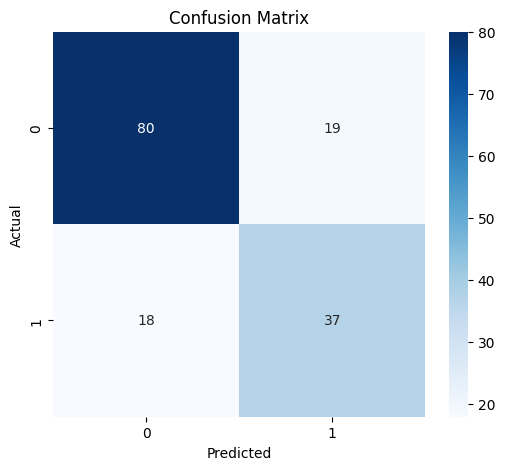

In [7]:
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns

# Generate the confusion matrix and visualize using heatmap
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()


In [8]:
21,35.7,75.0,102.5,112,0.148

(21, 35.7, 75.0, 102.5, 112, 0.148)

---
# Part C — Prediction Dashboard (FastAPI + HTML frontend)

The trained model is served by sir's FastAPI app (`lab06/main.py`) and the user enters the six
feature values in `lab06/index.html`. The page calls `POST /predict` and shows the result:

![Diabetes Prediction Dashboard](dashboard.png)

Run it locally:
```
cd lab06
python -m uvicorn main:app --port 8000
```
then open `index.html` in the browser (it calls `http://localhost:8000/predict`).
API docs: `http://localhost:8000/docs`.

In [9]:
# Download the trained model (.pkl) so this notebook runs anywhere (e.g. Colab),
# then load it and verify it predicts.
import os
import pickle
import pandas as pd

PKL_URL = 'https://raw.githubusercontent.com/manaal6/Introduction_To_AI_Lab_Tasks/main/lab06/diabetes_model.pkl'
PKL_LOCAL = 'diabetes_model.pkl'

if not os.path.exists(PKL_LOCAL):
    print('Downloading:', PKL_URL)
    import urllib.request
    urllib.request.urlretrieve(PKL_URL, PKL_LOCAL)
print('Using:', PKL_LOCAL)

with open(PKL_LOCAL, 'rb') as f:
    clf = pickle.load(f)

print('Model:', type(clf).__name__)
print('Features:', list(clf.feature_names_in_))

# Sanity check: one sample prediction with feature names (no warning)
sample = pd.DataFrame([{
    'Age': 40, 'BMI': 30.0, 'BloodPressure': 70,
    'Insulin': 80, 'Glucose': 120, 'DiabetesPedigreeFunction': 0.5,
}])
pred = int(clf.predict(sample)[0])
prob = float(clf.predict_proba(sample)[0][1])
print(f'Predicted: {pred} ({"Diabetic" if pred else "Not Diabetic"}), P(diabetic)={prob:.3f}')


Using: diabetes_model.pkl
Model: LogisticRegression
Features: ['Age', 'BMI', 'BloodPressure', 'Insulin', 'Glucose', 'DiabetesPedigreeFunction']
Predicted: 0 (Not Diabetic), P(diabetic)=0.257


C:\Program Files\Python313\Lib\site-packages\sklearn\base.py:525: InconsistentVersionWarning: Trying to unpickle estimator LogisticRegression from version 1.6.1 when using version 1.9.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
